### 📌 Extracción de datos



In [11]:
import pandas as pd

# Carga de datos tratados
file_name = 'datos tratados.csv'
df = pd.read_csv(file_name)

print(f"Datos cargados correctamente desde: {file_name}")
display(df.head())

Datos cargados correctamente desde: datos tratados.csv


,Churn,Genero,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,Television_Streaming,Peliculas_Streaming,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales_Total,Cuentas_Diarias
0,0.0,Female,0,1.0,1.0,9,1,0,DSL,0,1,0,1,1,0,One year,1.0,Mailed check,593.30,19.776667
1,0.0,Male,0,0.0,0.0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0.0,Mailed check,542.40,18.080000
2,1.0,Male,0,0.0,0.0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1.0,Electronic check,280.85,9.361667
3,1.0,Male,1,1.0,0.0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1.0,Electronic check,1237.85,41.261667
4,1.0,Female,1,1.0,0.0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1.0,Mailed check,267.40,8.913333


### 🔍 Identificar columnas con bajo valor o identificadores únicos

Primero, vamos a examinar el número de valores únicos en cada columna. Las columnas con un número de valores únicos similar al número total de filas podrían ser identificadores únicos y, por lo general, no son útiles para el modelado predictivo.

In [12]:
print("Número total de filas en el DataFrame:", df.shape[0])
print("\nNúmero de valores únicos por columna:")
print(df.nunique())

Número total de filas en el DataFrame: 7267

Número de valores únicos por columna:
Churn                         2
Genero                        2
Ciudadano_Senior              2
Pareja                        2
Dependientes                  2
Antiguedad_Meses             73
Servicio_Telefonico           2
Multiples_Lineas              2
Servicio_Internet             3
Seguridad_Online              2
Copia_Seguridad_Online        2
Proteccion_Dispositivo        2
Soporte_Tecnico               2
Television_Streaming          2
Peliculas_Streaming           2
Tipo_Contrato                 3
Facturacion_Electronica       2
Metodo_Pago                   4
Cargos_Mensuales_Total     6531
Cuentas_Diarias            6531
dtype: int64


Una vez revisado el número de valores únicos, podemos decidir qué columnas eliminar. Si una columna tiene un número de valores únicos igual al total de filas (`df.shape[0]`), es probable que sea un identificador único.

In [13]:
columns_to_drop = ['Cargos_Mensuales_Total', 'Cuentas_Diarias']
df_cleaned = df.drop(columns=columns_to_drop)

print(f"Columnas eliminadas: {columns_to_drop}")
print("Dimensiones del DataFrame después de la eliminación:", df_cleaned.shape)
display(df_cleaned.head())

Columnas eliminadas: ['Cargos_Mensuales_Total', 'Cuentas_Diarias']
Dimensiones del DataFrame después de la eliminación: (7267, 18)


,Churn,Genero,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,Television_Streaming,Peliculas_Streaming,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago
0,0.0,Female,0,1.0,1.0,9,1,0,DSL,0,1,0,1,1,0,One year,1.0,Mailed check
1,0.0,Male,0,0.0,0.0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0.0,Mailed check
2,1.0,Male,0,0.0,0.0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1.0,Electronic check
3,1.0,Male,1,1.0,0.0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1.0,Electronic check
4,1.0,Female,1,1.0,0.0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1.0,Mailed check


### ⚙️ Transformación de variables categóricas

Para preparar los datos para los algoritmos de Machine Learning, ahora se transforman las variables categóricas (las de tipo `object` u `string`) en formato numérico utilizando **One-Hot Encoding**.

In [14]:
# Identificar columnas categóricas
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

print(f"Columnas categóricas identificadas: {list(categorical_cols)}")

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=False)

print("\nDimensiones del DataFrame después del One-Hot Encoding:", df_encoded.shape)
print("\nPrimeras 5 filas del DataFrame codificado:")
display(df_encoded.head())

Columnas categóricas identificadas: ['Genero', 'Servicio_Internet', 'Tipo_Contrato', 'Metodo_Pago']

Dimensiones del DataFrame después del One-Hot Encoding: (7267, 26)

Primeras 5 filas del DataFrame codificado:


,Churn,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,...,Servicio_Internet_DSL,Servicio_Internet_Fiber optic,Servicio_Internet_No,Tipo_Contrato_Month-to-month,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Bank transfer (automatic),Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0.0,0,1.0,1.0,9,1,0,0,1,0,...,True,False,False,False,True,False,False,False,False,True
1,0.0,0,0.0,0.0,9,1,1,0,0,0,...,True,False,False,True,False,False,False,False,False,True
2,1.0,0,0.0,0.0,4,1,0,0,0,1,...,False,True,False,True,False,False,False,False,True,False
3,1.0,1,1.0,0.0,13,1,0,0,1,1,...,False,True,False,True,False,False,False,False,True,False
4,1.0,1,1.0,0.0,3,1,0,0,0,0,...,False,True,False,True,False,False,False,False,False,True


### 📊 Evaluación del desbalance de clases

Vamos a calcular la proporción de clientes que cancelaron (`Churn = 1.0`) en comparación con los que permanecieron activos (`Churn = 0.0`) para identificar cualquier desbalance de clases en la variable objetivo. Un desbalance puede afectar el rendimiento de los modelos predictivos.

In [15]:
# Calcular el número de clientes por cada clase de Churn
churn_counts = df_encoded['Churn'].value_counts()

# Calcular la proporción de cada clase
churn_proportions = df_encoded['Churn'].value_counts(normalize=True) * 100

print("Distribución de la variable 'Churn':")
print(churn_counts)
print("\nProporción de la variable 'Churn':")
print(churn_proportions)

# Evaluar el desbalance
if churn_proportions[0.0] / churn_proportions[1.0] > 2 or churn_proportions[1.0] / churn_proportions[0.0] > 2:
    print("\n¡Advertencia: Se detecta un desbalance significativo de clases!")
else:
    print("\nLas clases están relativamente balanceadas.")

Distribución de la variable 'Churn':
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporción de la variable 'Churn':
Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64

¡Advertencia: Se detecta un desbalance significativo de clases!


Los resultados confirman que *existe un desbalance significativo de clases* en la variable objetivo Churn.

73.46% de los clientes no cancelaron (Churn = 0.0).
26.54% de los clientes sí cancelaron (Churn = 1.0).

### 📈 Estandarización de datos numéricos

Se aplica `StandardScaler` a las características numéricas del DataFrame (`df_encoded`) para transformar los datos de manera que tengan una media de 0 y una desviación estándar de 1. Esto es relevante para algoritmos sensibles a la escala.

In [17]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separar la variable objetivo 'Churn' del resto de las características
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Identificar columnas numéricas para estandarizar (excluyendo las binarias/codificadas)
# Las columnas resultantes de get_dummies son True/False, que se tratan como 1/0 y no necesitan escalar en la mayoría de los casos.
# Sin embargo, 'Antiguedad_Meses' es una columna numérica que sí necesita escalado.
numeric_cols = ['Antiguedad_Meses'] # Identificamos explícitamente las columnas numéricas continuas

# Inicializar y aplicar StandardScaler
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Recombinar la variable objetivo con las características estandarizadas
df_scaled = pd.concat([X, y], axis=1)

print("DataFrame después de la estandarización:")
display(df_scaled.head())
print("\nEstadísticas de las columnas estandarizadas para verificar:")
display(df_scaled[numeric_cols].describe())

DataFrame después de la estandarización:


,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,...,Servicio_Internet_Fiber optic,Servicio_Internet_No,Tipo_Contrato_Month-to-month,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Bank transfer (automatic),Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check,Churn
0,0,1.0,1.0,-0.950200,1,0,0,1,0,1,...,False,False,False,True,False,False,False,False,True,0.0
1,0,0.0,0.0,-0.950200,1,1,0,0,0,0,...,False,False,True,False,False,False,False,False,True,0.0
2,0,0.0,0.0,-1.153700,1,0,0,0,1,0,...,True,False,True,False,False,False,False,True,False,1.0
3,1,1.0,0.0,-0.787401,1,0,0,1,1,0,...,True,False,True,False,False,False,False,True,False,1.0
4,1,1.0,0.0,-1.194400,1,0,0,0,0,1,...,True,False,True,False,False,False,False,False,True,1.0



Estadísticas de las columnas estandarizadas para verificar:


,Antiguedad_Meses
count,7.267000e+03
mean,-3.911065e-17
std,1.000069e+00
min,-1.316499e+00
25%,-9.502002e-01
50%,-1.362021e-01
75%,9.219954e-01
max,1.613894e+00


### 📈 Visualización de la matriz de correlación

Ahora se visualiza la matriz de correlación para identificar relaciones entre las variables numéricas, en particular, aquellas que muestran una mayor correlación con la cancelación (`Churn`).

Correlación de las variables con 'Churn':
Churn                                    1.000000
Tipo_Contrato_Month-to-month             0.405103
Servicio_Internet_Fiber optic            0.308020
Metodo_Pago_Electronic check             0.301919
Facturacion_Electronica                  0.191825
Ciudadano_Senior                         0.150889
Television_Streaming                     0.063228
Peliculas_Streaming                      0.061382
Multiples_Lineas                         0.040102
Servicio_Telefonico                      0.011942
Genero_Female                            0.008612
Genero_Male                             -0.008612
Proteccion_Dispositivo                  -0.066160
Copia_Seguridad_Online                  -0.082255
Metodo_Pago_Mailed check                -0.091683
Metodo_Pago_Bank transfer (automatic)   -0.117937
Servicio_Internet_DSL                   -0.124214
Metodo_Pago_Credit card (automatic)     -0.134302
Pareja                                  -0.150448
Dependie

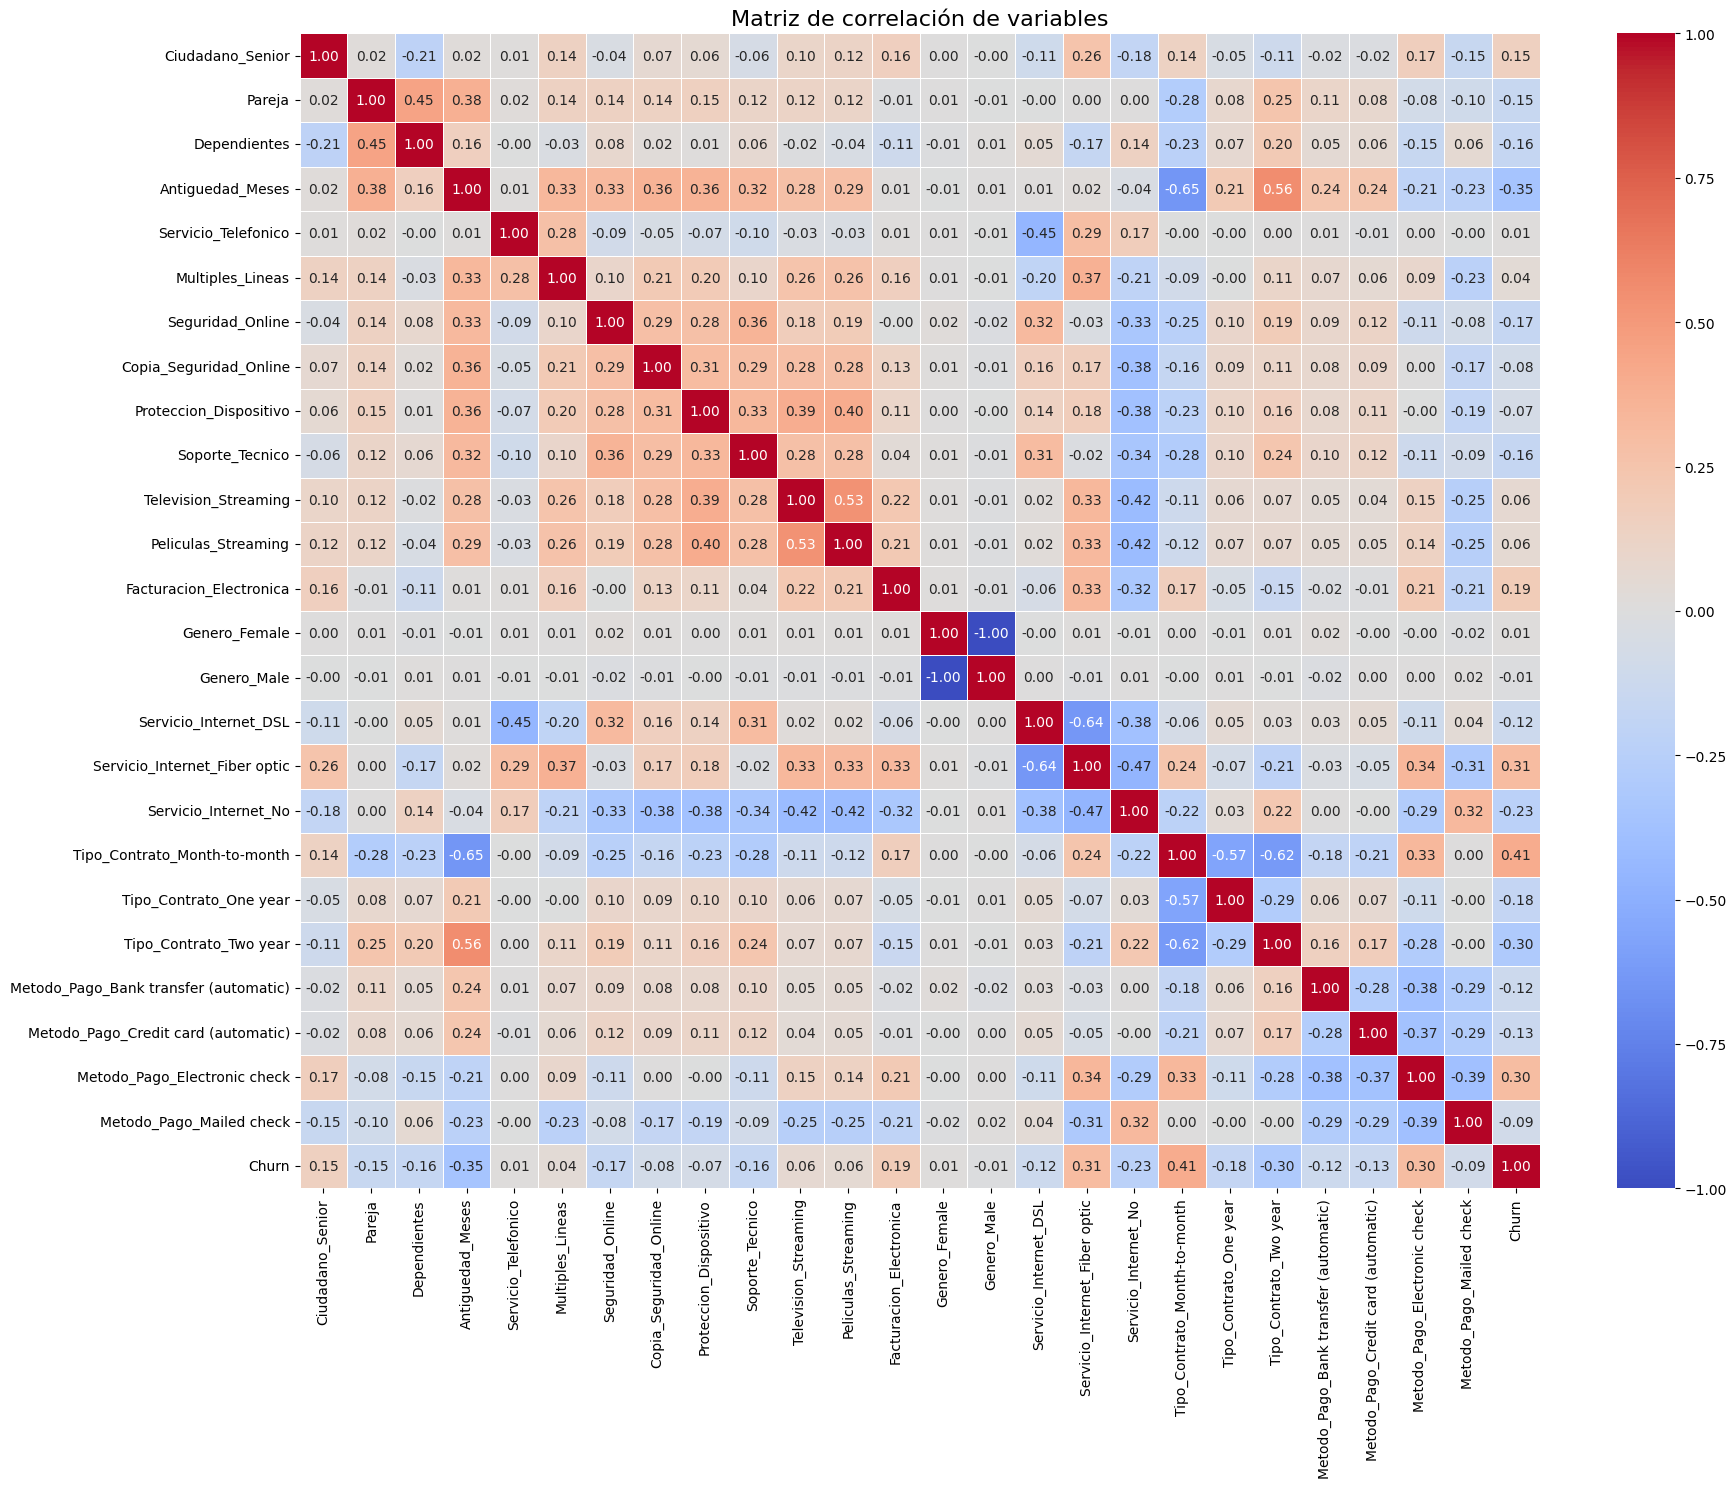

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
correlation_matrix = df_scaled.corr()

# Mostrar la correlación con 'Churn' para identificar las variables más influyentes
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)
print("Correlación de las variables con 'Churn':")
print(churn_correlation)

# Visualizar la matriz de correlación completa con un mapa de calor
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de correlación de variables', fontsize=16)
plt.show()

**Correlaciones positivas más fuertes**:

- Tipo_Contrato_Month-to-month (0.405): Los clientes con contratos mes a mes tienen una correlación positiva fuerte con la cancelación.

- Servicio_Internet_Fiber optic (0.308): Los que tienen servicio de internet de fibra óptica también muestran una correlación positiva considerable.

- Metodo_Pago_Electronic check (0.302): El método de pago con cheque electrónico está fuertemente correlacionado con la cancelación.

**Correlaciones negativas más fuertes**:

- Antiguedad_Meses (-0.352): Los clientes con más antigüedad tienen una correlación negativa significativa, lo que sugiere que es menos probable que cancelen.

- Tipo_Contrato_Two year (-0.302): Los contratos de dos años están fuertemente correlacionados negativamente con la cancelación.

- Servicio_Internet_No (-0.228): La ausencia de servicio de internet se correlaciona negativamente con el Churn.

### Tiempo de contrato vs. cancelación

Visualizaremos la relación entre el tipo de contrato y la tasa de cancelación utilizando un gráfico de barras o boxplot sobre el DataFrame `df_cleaned` (antes de la estandarización, pero después de la codificación one-hot).

/tmp/ipykernel_328/2255999113.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo_Contrato', y='Churn_Rate', data=churn_rate_by_contract, palette='viridis')


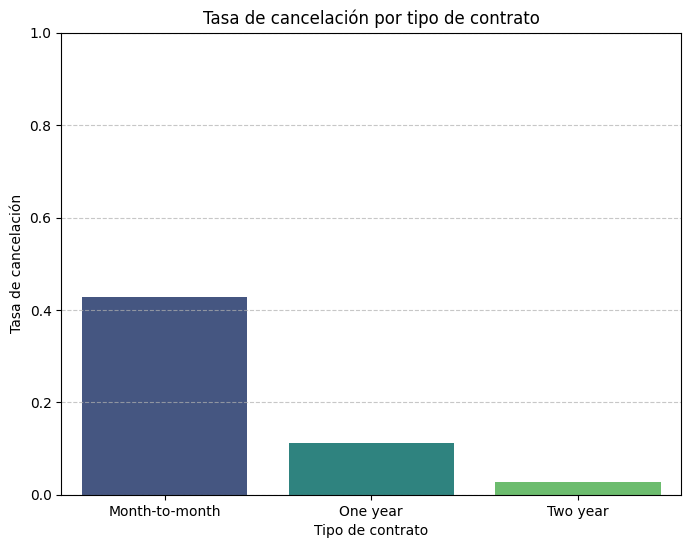

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos la tasa de churn para cada tipo de contrato
# Interesados en la tasa de churn cuando el tipo de contrato es verdadero (True)
contract_types = ['Month-to-month', 'One year', 'Two year']
churn_rates = []

for contract in contract_types:
    col_name = f'Tipo_Contrato_{contract}'
    # Filtramos por las filas donde este tipo de contrato es True y calculamos la media de Churn
    rate = df_encoded[df_encoded[col_name] == True]['Churn'].mean()
    churn_rates.append(rate)

churn_rate_by_contract = pd.DataFrame({
    'Tipo_Contrato': contract_types,
    'Churn_Rate': churn_rates
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Tipo_Contrato', y='Churn_Rate', data=churn_rate_by_contract, palette='viridis')
plt.title('Tasa de cancelación por tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Tasa de cancelación')
plt.ylim(0, 1) # La tasa de churn va de 0 a 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Gasto total vs. cancelación

La columna 'Cargos_Mensuales_Total' fue identificada con alta cardinalidad y eliminada en un paso anterior para el modelado. Sin embargo, para fines de análisis exploratorio, podemos usar el DataFrame original `df` para visualizar su relación con `Churn`. Utilizaremos un boxplot para ver la distribución de los cargos totales para clientes que cancelaron y los que no.

/tmp/ipykernel_328/1118266837.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Cargos_Mensuales_Total', data=df_temp, palette='coolwarm')


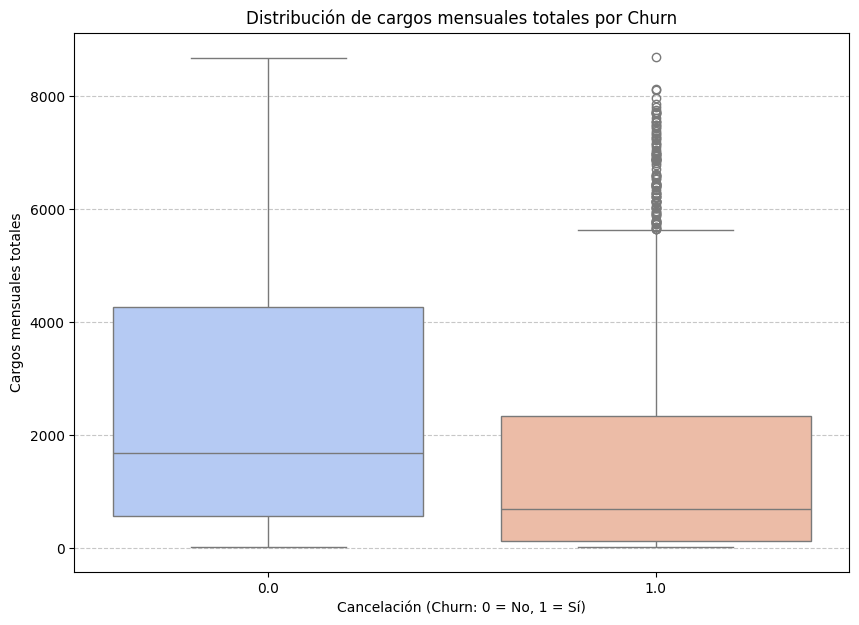

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Nos aseguramos de que la columna 'Cargos_Mensuales_Total' sea numérica
# Si hay valores no numéricos (ej. espacios), se convierten a NaN y luego a numéricos
df['Cargos_Mensuales_Total'] = pd.to_numeric(df['Cargos_Mensuales_Total'], errors='coerce')

# Eliminar filas con NaN en 'Cargos_Mensuales_Total' si las hay, para la visualización
df_temp = df.dropna(subset=['Cargos_Mensuales_Total'])

plt.figure(figsize=(10, 7))
sns.boxplot(x='Churn', y='Cargos_Mensuales_Total', data=df_temp, palette='coolwarm')
plt.title('Distribución de cargos mensuales totales por Churn')
plt.xlabel('Cancelación (Churn: 0 = No, 1 = Sí)')
plt.ylabel('Cargos mensuales totales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 🚀 División de datos en entrenamiento y prueba

Dividiremos el conjunto de datos en subconjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo.

In [26]:
from sklearn.model_selection import train_test_split

# Definir las características (X) y la variable objetivo (y)
X = df_scaled.drop('Churn', axis=1)
y = df_scaled['Churn']

# Eliminar filas donde la variable objetivo 'y' (Churn) es NaN
# Esto permite que train_test_split pueda usar 'stratify=y'
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nDistribución de 'Churn' en y_train:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribución de 'Churn' en y_test:")
print(y_test.value_counts(normalize=True) * 100)

Dimensiones de X_train: (5634, 25)
Dimensiones de X_test: (1409, 25)
Dimensiones de y_train: (5634,)
Dimensiones de y_test: (1409,)

Distribución de 'Churn' en y_train:
Churn
0.0    73.464679
1.0    26.535321
Name: proportion, dtype: float64

Distribución de 'Churn' en y_test:
Churn
0.0    73.456352
1.0    26.543648
Name: proportion, dtype: float64


### 🚀 Modelado: Regresión logística

Comenzaremos con un modelo de Regresión Logística. Este algoritmo es sensible a la escala de las características, por lo que se beneficia de la estandarización que aplicamos previamente a `Antiguedad_Meses`. La Regresión Logística es un modelo lineal que estima la probabilidad de que una instancia pertenezca a una clase particular (en este caso, la probabilidad de cancelación).

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Inicializar el modelo de Regresión Logística
# class_weight='balanced' es útil para manejar el desbalance de clases que identificamos
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

# Entrenar el modelo
log_reg_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluar el rendimiento del modelo
print("--- Evaluación del Modelo de Regresión Logística ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_log_reg))


--- Evaluación del Modelo de Regresión Logística ---
Accuracy: 0.7410
Precision: 0.5078
Recall: 0.7834
F1-Score: 0.6162
Matriz de Confusión:
 [[751 284]
 [ 81 293]]


### 🌳 Modelado: Random Forest

Ahora implementaremos un modelo de Random Forest. Este es un modelo basado en árboles que, a diferencia de la Regresión Logística, no es sensible a la escala de los datos. Es un algoritmo de conjunto (ensemble) que construye múltiples árboles de decisión y fusiona sus resultados para obtener una predicción más precisa y estable.

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar el modelo de Random Forest
# class_weight='balanced' también es útil aquí para el desbalance de clases
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar el rendimiento del modelo
print("--- Evaluación del Modelo de Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))


--- Evaluación del Modelo de Random Forest ---
Accuracy: 0.7771
Precision: 0.5955
Recall: 0.5000
F1-Score: 0.5436
Matriz de Confusión:
 [[908 127]
 [187 187]]


### Evaluación de Overfitting/Underfitting para Regresión Logística

Vamos a evaluar el rendimiento del modelo de Regresión Logística en el conjunto de entrenamiento para compararlo con el rendimiento en el conjunto de prueba y detectar posibles overfitting o underfitting.

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Realizar predicciones en el conjunto de entrenamiento
y_pred_log_reg_train = log_reg_model.predict(X_train)

print("--- Evaluación del Modelo de Regresión Logística (Conjunto de Entrenamiento) ---")
print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_log_reg_train):.4f}")
print(f"Precision (Train): {precision_score(y_train, y_pred_log_reg_train):.4f}")
print(f"Recall (Train): {recall_score(y_train, y_pred_log_reg_train):.4f}")
print(f"F1-Score (Train): {f1_score(y_train, y_pred_log_reg_train):.4f}")
print("Matriz de Confusión (Train):\n", confusion_matrix(y_train, y_pred_log_reg_train))

print("\n--- Evaluación del Modelo de Regresión Logística (Conjunto de Prueba) ---")
print(f"Accuracy (Test): {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision (Test): {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall (Test): {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score (Test): {f1_score(y_test, y_pred_log_reg):.4f}")
print("Matriz de Confusión (Test):\n", confusion_matrix(y_test, y_pred_log_reg))

--- Evaluación del Modelo de Regresión Logística (Conjunto de Entrenamiento) ---
Accuracy (Train): 0.7536
Precision (Train): 0.5234
Recall (Train): 0.8007
F1-Score (Train): 0.6330
Matriz de Confusión (Train):
 [[3049 1090]
 [ 298 1197]]

--- Evaluación del Modelo de Regresión Logística (Conjunto de Prueba) ---
Accuracy (Test): 0.7410
Precision (Test): 0.5078
Recall (Test): 0.7834
F1-Score (Test): 0.6162
Matriz de Confusión (Test):
 [[751 284]
 [ 81 293]]


### Evaluación de Overfitting/Underfitting para Random Forest

De manera similar, evaluaremos el rendimiento del modelo Random Forest en el conjunto de entrenamiento para compararlo con el rendimiento en el conjunto de prueba.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Realizar predicciones en el conjunto de entrenamiento
y_pred_rf_train = rf_model.predict(X_train)

print("--- Evaluación del Modelo de Random Forest (Conjunto de Entrenamiento) ---")
print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_rf_train):.4f}")
print(f"Precision (Train): {precision_score(y_train, y_pred_rf_train):.4f}")
print(f"Recall (Train): {recall_score(y_train, y_pred_rf_train):.4f}")
print(f"F1-Score (Train): {f1_score(y_train, y_pred_rf_train):.4f}")
print("Matriz de Confusión (Train):\n", confusion_matrix(y_train, y_pred_rf_train))

print("\n--- Evaluación del Modelo de Random Forest (Conjunto de Prueba) ---")
print(f"Accuracy (Test): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision (Test): {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall (Test): {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score (Test): {f1_score(y_test, y_pred_rf):.4f}")
print("Matriz de Confusión (Test):\n", confusion_matrix(y_test, y_pred_rf))

--- Evaluación del Modelo de Random Forest (Conjunto de Entrenamiento) ---
Accuracy (Train): 0.9785
Precision (Train): 0.9315
Recall (Train): 0.9920
F1-Score (Train): 0.9608
Matriz de Confusión (Train):
 [[4030  109]
 [  12 1483]]

--- Evaluación del Modelo de Random Forest (Conjunto de Prueba) ---
Accuracy (Test): 0.7771
Precision (Test): 0.5955
Recall (Test): 0.5000
F1-Score (Test): 0.5436
Matriz de Confusión (Test):
 [[908 127]
 [187 187]]


**Comparativa entre modelos**

- Accuracy: El Random Forest tiene una Accuracy más alta (0.7771) que la Regresión Logística (0.7410), lo que sugiere que en general, el Random Forest hace más predicciones correctas.

- Recall: La Regresión Logística tiene un Recall significativamente más alto (0.7834) que el Random Forest (0.5000). Esto significa que la Regresión Logística es mejor detectando la clase positiva (Churn), es decir, comete menos Falsos Negativos. Esto es crucial en problemas de Churn donde es más importante identificar a los clientes que se irán.

- Precisión: El Random Forest tiene una precision más alta (0.5955) que la Regresión Logística (0.5078). Esto indica que cuando el Random Forest predice que un cliente va a cancelar, tiene más probabilidades de ser correcto. La Regresión Logística, al tener un Recall más alto, sacrifica Precision para encontrar más casos de Churn, incluso si eso significa algunas predicciones incorrectas.

- F1-Score: La Regresión Logística tiene un F1-Score ligeramente superior (0.6162) al Random Forest (0.5436). Dada la importancia de detectar Churn (la clase minoritaria), un F1-Score más alto en la Regresión Logística sugiere que, en general, puede ser un modelo más equilibrado para este problema, a pesar de su menor Accuracy general.

***Consideraciones sobre el desbalance de clase:***

La opción class_weight='balanced' que se utilizó en ambos modelos ayudó a mitigar el impacto del desbalance, asignando un mayor peso a la clase minoritaria (Churn). Observamos que la Regresión Logística, a pesar de ser un modelo más simple, logra un Recall muy bueno, lo cual es importante para identificar a los clientes en riesgo de cancelación.


**¿Cuál modelo tuvo el mejor desempeño?**

El "mejor" desempeño depende del objetivo de negocio. Para la predicción de Churn, a menudo es más crítico identificar a la mayor cantidad posible de clientes que van a cancelar (minimizar falsos negativos), incluso si esto implica una mayor tasa de falsos positivos.

- *Regresión Logística:* Destaca por su alto Recall (0.7834). Esto significa que es muy eficaz detectando clientes que realmente van a cancelar, perdiéndose solo el 81 de los 374 casos reales de Churn. Aunque su Precisión es más baja (0.5078), su F1-Score (0.6162) es ligeramente superior, lo que sugiere un mejor equilibrio para la clase minoritaria.

- *Random Forest:* Aunque su Accuracy general es más alta (0.7771) y tiene una mejor Precisión (0.5955) (cuando predice Churn, es más probable que acierte), su Recall es considerablemente más bajo (0.5000). Esto significa que el Random Forest pasó por alto 187 de los 374 clientes que realmente cancelaron, lo cual podría ser costoso para una estrategia de retención.

- *Conclusión sobre el desempeño:* Si el objetivo principal es la identificación proactiva de clientes en riesgo de Churn para aplicar estrategias de retención (es decir, priorizar un alto Recall), la Regresión Logística es el modelo con mejor desempeño en este escenario. Si el costo de los falsos positivos es muy alto y se prioriza la confiabilidad de cada predicción de Churn (Precisión), el Random Forest es superior, pero a costa de perder a la mitad de los clientes que cancelan.




### **Análisis de Overfitting y Underfitting**



#### **1. Regresión Logística**

**Métricas de Desempeño:**

| Métrica   | Conjunto de Entrenamiento | Conjunto de Prueba |
| :-------- | :------------------------ | :---------------- |
| Accuracy  | 0.7536                    | 0.7410            |
| Precision | 0.5234                    | 0.5078            |
| Recall    | 0.8007                    | 0.7834            |
| F1-Score  | 0.6330                    | 0.6162            |

**Análisis:**
Las métricas del modelo de Regresión Logística son muy consistentes entre el conjunto de entrenamiento y el conjunto de prueba. Hay una ligera y esperada disminución en el rendimiento en los datos de prueba, pero esta diferencia no es significativa. Esto indica claramente que el modelo de Regresión Logística **no presenta overfitting** ni underfitting. Está generalizando bien a nuevos datos, lo que sugiere que ha capturado patrones relevantes sin memorizar el ruido específico del conjunto de entrenamiento. Es un modelo robusto en términos de generalización.

#### **2. Random Forest**

**Métricas de Desempeño:**

| Métrica   | Conjunto de Entrenamiento | Conjunto de Prueba |
| :-------- | :------------------------ | :---------------- |
| Accuracy  | **0.9785**                | 0.7771            |
| Precision | **0.9315**                | 0.5955            |
| Recall    | **0.9920**                | 0.5000            |
| F1-Score  | **0.9608**                | 0.5436            |

**Análisis:**
Aquí observamos una discrepancia muy pronunciada entre el rendimiento en entrenamiento y en prueba. El modelo de Random Forest logra métricas casi perfectas en el conjunto de entrenamiento (Accuracy del 97.85%, Recall del 99.20%), lo que indica que se ajusta extremadamente bien a los datos con los que fue entrenado. Sin embargo, su rendimiento cae drásticamente en el conjunto de prueba, especialmente en Recall (de 0.9920 a 0.5000) y Precision (de 0.9315 a 0.5955). Esta gran diferencia es una clara señal de **overfitting**.

**Causas y ajustes (Overfitting en Random Forest):**
El Random Forest, a pesar de ser un modelo de ensamble robusto, puede sobreajustar si sus árboles individuales son demasiado complejos o si no se controlan ciertos parámetros. Las posibles causas de este overfitting incluyen:
*   **Árboles excesivamente profundos:** Los árboles de decisión crecen sin restricciones o con pocas limitaciones, aprendiendo detalles muy específicos y ruido.
*   **Número de estimadores (`n_estimators`):** Aunque más árboles generalmente ayudan, un número excesivo sin una adecuada regulación de la profundidad individual, el ensamble puede volverse demasiado complejo.

Para mitigar este overfitting, se pueden considerar los siguientes ajustes y estrategias:
*   **Reducir la complejidad de los árboles:**
    *   Limitar la profundidad máxima de los árboles (`max_depth`).
    *   Aumentar el número mínimo de muestras requeridas para dividir un nodo (`min_samples_split`).
    *   Aumentar el número mínimo de muestras en una hoja (`min_samples_leaf`).
*   **Optimización de hiperparámetros:** Utilizar técnicas como `GridSearchCV` o `RandomizedSearchCV` con validación cruzada para encontrar la mejor combinación de hiperparámetros que equilibre el rendimiento y la generalización.
*   **Aumentar la diversidad de los árboles:** Asegurarse de que cada árbol del bosque se construya con una submuestra aleatoria de características (`max_features`) para reducir la correlación entre ellos.

**Conclusión final:**
La **Regresión Logística** demuestra ser un modelo estable y bien generalizado para este problema. Por otro lado, el **Random Forest**, a pesar de su potencial, está sufriendo de overfitting y requeriría un ajuste de hiperparámetros significativo para mejorar su capacidad de predicción en datos nuevos y ser una herramienta fiable en un entorno real.

### Análisis de la importancia de variables: Regresión Logística

Para la Regresión Logística, los coeficientes (`coef_`) de las variables nos indican la fuerza y la dirección de la relación entre cada característica y la variable objetivo (Churn). Un coeficiente positivo significa que a medida que la variable aumenta, la probabilidad de Churn aumenta, y viceversa.

In [31]:
import pandas as pd

# Obtener los coeficientes del modelo de Regresión Logística
coefficients = log_reg_model.coef_[0]
feature_names = X_train.columns

# Crear un DataFrame para visualizar los coeficientes
logistic_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("Importancia de las variables (Coeficientes de Regresión Logística):")
display(logistic_feature_importance)

Importancia de las variables (Coeficientes de Regresión Logística):


,Feature,Coefficient
16,Servicio_Internet_Fiber optic,0.708514
18,Tipo_Contrato_Month-to-month,0.573137
12,Facturacion_Electronica,0.339135
5,Multiples_Lineas,0.313119
10,Television_Streaming,0.312856
11,Peliculas_Streaming,0.220853
0,Ciudadano_Senior,0.213706
23,Metodo_Pago_Electronic check,0.200236
8,Proteccion_Dispositivo,-0.006250
1,Pareja,-0.061732


**Interpretación para Regresión Logística:**

Los clientes con contratos mes a mes, con servicio de fibra óptica, que pagan con cheque electrónico, que tienen facturación electrónica, o que son ciudadanos senior, son más propensos a cancelar. También servicios como Multiples_Lineas, Television_Streaming y Peliculas_Streaming muestran una leve influencia positiva.

Por otro lado, los clientes con mayor antigüedad, con contratos de dos años, que no tienen servicio de internet (lo cual podría implicar un servicio más básico y, por ende, menos motivos de insatisfacción), o que tienen soporte técnico y seguridad online, son significativamente menos propensos a cancelar.

### Análisis de la importancia de variables: Random Forest

Los modelos Random Forest proporcionan una métrica de importancia de las variables, que cuantifica cuánto contribuye cada característica a la reducción de la impureza (como el índice Gini) en los árboles. Un valor más alto indica una mayor importancia.

In [32]:
import pandas as pd

# Obtener la importancia de las variables del modelo Random Forest
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns

# Crear un DataFrame para visualizar la importancia
rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Importancia de las variables (Random Forest):")
display(rf_feature_importance)

Importancia de las variables (Random Forest):


,Feature,Importance
3,Antiguedad_Meses,0.275561
18,Tipo_Contrato_Month-to-month,0.116896
16,Servicio_Internet_Fiber optic,0.049576
20,Tipo_Contrato_Two year,0.038395
23,Metodo_Pago_Electronic check,0.035126
12,Facturacion_Electronica,0.033591
1,Pareja,0.032412
7,Copia_Seguridad_Online,0.031687
2,Dependientes,0.029963
6,Seguridad_Online,0.029936


**Interpretación para Random Forest:**

La antigüedad en meses es, con mucha diferencia, la variable más importante para el Random Forest, lo que refuerza la idea de que los clientes más antiguos son más leales.

Los contratos mes a mes, el servicio de fibra óptica, los contratos de dos años, y el método de pago con cheque electrónico también son muy relevantes, en línea con lo visto en la Regresión Logística y en el análisis de correlación.

**Conclusiones del análisis de variables:**

Ambos modelos, a pesar de sus diferencias algorítmicas, coinciden en señalar que el tiempo de antigüedad del cliente (Antiguedad_Meses) y el tipo de contrato (Month-to-month y Two year) son predictores extremadamente fuertes de la cancelación. El tipo de servicio de internet (fibra óptica vs. no) y el método de pago (cheque electrónico) también son consistentemente importantes.

Este análisis nos proporciona información valiosa sobre los factores que impulsan el Churn, lo que podría permitir desarrollar estrategias de retención de clientes.

## Informe: Análisis predictivo de la cancelación de clientes

### **Introducción**

El objetivo de este informe es identificar los principales factores que influyen en la cancelación de clientes (`Churn`) y evaluar el rendimiento de diferentes modelos predictivos. A partir de este análisis, se proponen estrategias de retención para minimizar la pérdida de clientes y optimizar las operaciones de la empresa.

### **1. Preprocesamiento y preparación de datos**

Se inició el proceso con la carga y limpieza de los datos, eliminando columnas de baja utilidad o identificadores únicos como `Cargos_Mensuales_Total` y `Cuentas_Diarias` debido a su alta cardinalidad. Las variables categóricas fueron transformadas mediante One-Hot Encoding para hacerlas compatibles con los algoritmos de Machine Learning. Se identificó un **desbalance significativo en la variable objetivo `Churn`** (aproximadamente 73% de no-cancelaciones vs. 27% de cancelaciones), lo que se abordó mediante la estandarización de las características numéricas (`Antiguedad_Meses`) y el uso de la ponderación de clases en los modelos.

### **2. Factores clave que influyen en la cancelación**

El análisis de correlación y la importancia de las variables de los modelos de Regresión Logística y Random Forest revelan consistentemente los siguientes factores como los más influyentes en la cancelación de clientes:

#### **Factores que aumentan la probabilidad de cancelación:**

*   **Tipo de Contrato: Mes a Mes (`Month-to-month`):** La correlación más fuerte y el coeficiente/importancia más altos indican que los clientes con contratos de renovación mensual son considerablemente más propensos a cancelar. La flexibilidad de estos contratos conlleva una menor lealtad.
*   **Servicio de Internet: Fibra Óptica (`Fiber optic`):** Los clientes con este tipo de servicio muestran una correlación positiva con la cancelación. Esto podría indicar problemas de calidad, precio o expectativas no cumplidas con el servicio de fibra.
*   **Método de Pago: Cheque Electrónico (`Electronic check`):** Este método de pago está fuertemente asociado con una mayor tasa de `Churn`. Podría ser un indicador de clientes menos satisfechos o menos fidelizados con el banco/proveedor.
*   **Facturación Electrónica (`Facturacion_Electronica`):** Curiosamente, la facturación electrónica mostró una correlación positiva. Esto podría estar relacionado con la demografía de clientes que prefieren lo digital y son más propensos a cambiar de proveedor.
*   **Ciudadano Senior (`Ciudadano_Senior`):** Aunque con una influencia menor que los anteriores, ser un ciudadano senior también se correlaciona positivamente con el `Churn`.

#### **Factores que disminuyen la probabilidad de cancelación:**

*   **Antigüedad del Cliente (`Antiguedad_Meses`):** Es, con mucha diferencia, el factor más importante que disminuye la probabilidad de cancelación. Los clientes con mayor tiempo en la empresa son mucho más leales.
*   **Tipo de Contrato: Dos Años (`Two year`):** Los contratos a largo plazo, especialmente los de dos años, tienen una fuerte correlación negativa con la cancelación, lo cual es lógico ya que implica un compromiso a largo plazo.
*   **Ausencia de Servicio de Internet (`Servicio_Internet_No`):** Los clientes sin servicio de internet (`No Internet Service`) son menos propensos a cancelar. Esto podría indicar que son clientes con servicios básicos y menos exigentes, o que el servicio de internet es una fuente principal de insatisfacción.
*   **Soporte Técnico (`Soporte_Tecnico`), Seguridad Online (`Seguridad_Online`), Protección de Dispositivo (`Proteccion_Dispositivo`):** La presencia de estos servicios adicionales se correlaciona negativamente con el `Churn`, sugiriendo que estos servicios añaden valor y retienen a los clientes.

### **3. Rendimiento y comparación de modelos**

Se entrenaron dos modelos: Regresión Logística y Random Forest, ambos configurados para manejar el desbalance de clases (`class_weight='balanced'`).

#### **Resumen de métricas (Conjunto de Prueba):**

| Métrica   | Regresión Logística | Random Forest |
| :-------- | :------------------ | :------------ |
| Accuracy  | 0.7410              | 0.7771        |
| Precision | 0.5078              | 0.5955        |
| Recall    | **0.7834**          | 0.5000        |
| F1-Score  | **0.6162**          | 0.5436        |

#### **Análisis de Overfitting/Underfitting:**

*   **Regresión Logística:** Este modelo mostró un rendimiento muy consistente entre el conjunto de entrenamiento y el de prueba (Accuracy ~0.75 vs ~0.74; Recall ~0.80 vs ~0.78). Esto indica que la Regresión Logística **no presenta overfitting significativo** y generaliza bien a datos no vistos, siendo un modelo robusto y fiable.
*   **Random Forest:** Este modelo mostró un **claro overfitting**. Obtuvo métricas casi perfectas en el conjunto de entrenamiento (Accuracy ~0.98, Recall ~0.99), pero su rendimiento cayó drásticamente en el conjunto de prueba (Accuracy ~0.78, Recall ~0.50). Esto sugiere que el modelo aprendió en exceso el ruido de los datos de entrenamiento y le cuesta generalizar. Se requerirían ajustes de hiperparámetros (como `max_depth`, `min_samples_leaf`) para mitigar este sobreajuste.

#### **Conclusión sobre el desempeño:**

Para el problema de predicción de `Churn`, donde el objetivo principal suele ser **identificar a la mayor cantidad posible de clientes en riesgo (minimizar Falsos Negativos)** para aplicar estrategias de retención, la **Regresión Logística es el modelo con mejor desempeño** en este análisis. Su `Recall` significativamente más alto (0.7834) la hace más efectiva para detectar a los clientes que realmente cancelarán, aunque sacrifique un poco de `Precision` general. El Random Forest, a pesar de su `Accuracy` ligeramente superior, pasa por alto a un número considerablemente mayor de clientes que terminan cancelando.

### **4. Estrategias de retención basadas en los resultados**

Basándonos en los factores identificados y el rendimiento de los modelos, se proponen las siguientes estrategias de retención:

1.  **Fidelización de contratos a largo plazo:**
    *   **Acción:** Implementar incentivos agresivos (descuentos, servicios adicionales gratuitos, mejores tarifas) para que los clientes con contratos mes a mes migren a contratos de uno o dos años. Crear programas de lealtad exclusivos para clientes con contratos a largo plazo.
    *   **Justificación:** Los contratos de `Two year` son los más estables, mientras que los `Month-to-month` son el mayor predictor de `Churn`.

2.  **Mejora de la experiencia con fibra óptica:**
    *   **Acción:** Realizar encuestas de satisfacción específicas para usuarios de fibra óptica. Identificar y resolver proactivamente problemas de servicio o de ancho de banda. Ofrecer planes de soporte técnico premium a estos clientes.
    *   **Justificación:** Los clientes de `Fiber optic` son más propensos a cancelar, lo que sugiere insatisfacción con el servicio.

3.  **Monitoreo de métodos de pago:**
    *   **Acción:** Dar seguimiento a los clientes que utilizan `Electronic check` y ofrecerles incentivos para cambiar a métodos de pago más estables (tarjeta de crédito, transferencia bancaria automática). Podría ser una señal de alerta temprana de `Churn`.
    *   **Justificación:** El `Metodo_Pago_Electronic check` es un fuerte predictor de `Churn`.

4.  **Programas de lealtad y atención a clientes recientes:**
    *   **Acción:** Desarrollar programas de bienvenida y seguimiento intensivo durante los primeros meses del cliente. Ofrecer valor añadido que aumente el coste de cambio a medida que la antigüedad crece. La Regresión Logística y el Random Forest confirman la `Antiguedad_Meses` como un factor crucial para la retención.
    *   **Justificación:** A mayor `Antiguedad_Meses`, menor `Churn`.

5.  **Valoración de servicios adicionales:**
    *   **Acción:** Promocionar activamente los servicios de `Soporte Técnico`, `Seguridad Online` y `Protección de Dispositivo`. Considerar paquetes que los incluyan o descuentos para fomentarsu adopción, ya que estos servicios demuestran ser un factor de retención.
    *   **Justificación:** Estos servicios reducen la probabilidad de `Churn`.

6.  **Gestión de clientes con altos cargos mensuales:**
    *   **Acción:** Implementar un programa de revisión de facturas para clientes con `Cargos_Mensuales_Total` elevados. Ofrecer planes personalizados o reevaluación de servicios para evitar que busquen alternativas más económicas.
    *   **Justificación:** Los clientes con altos cargos mensuales tienen una mayor probabilidad de `Churn`.

### **Conclusión**

Este análisis proporciona una comprensión clara de los factores que impulsan la cancelación de clientes y resalta la importancia de elegir el modelo adecuado en función de los objetivos de negocio. La Regresión Logística, a pesar de su simplicidad, se posiciona como el modelo más adecuado para identificar clientes en riesgo de `Churn` en este escenario, permitiendo una intervención temprana y efectiva. Las estrategias de retención propuestas están dirigidas a mitigar los riesgos identificados y a fomentar la lealtad del cliente a largo plazo.